In [7]:
should_plot_mcmc_hyp_distribution

True

In [3]:
from pypdf import PdfReader, PdfWriter

# Наша таблица с границами лекций
lectures = {
    "Lecture_01.pdf": (1, 7),
    "Lecture_02.pdf": (7, 14),
    "Lecture_03.pdf": (14, 21),
    "Lecture_04.pdf": (22, 38),
    "Lecture_05.pdf": (39, 49),
    "Lecture_06.pdf": (49, 63),
    "Lecture_07.pdf": (63, 74),
    "Lecture_08.pdf": (75, 82),
    "Lecture_09.pdf": (83, 94),
    "Lecture_10.pdf": (95, 102),
    "Lecture_11.pdf": (103, 108),
    "Lecture_12.pdf": (109, 113),
    "Lecture_13.pdf": (114, 118)
}

reader = PdfReader("Лекции (4).pdf")

for filename, (start_page, end_page) in lectures.items():
    writer = PdfWriter()
    # В Python индексы начинаются с 0, поэтому вычитаем 1 из начальной страницы.
    # Конечная страница не требует вычитания, так как range() не включает верхнюю границу,
    # а наша таблица подразумевает включение конечной страницы.
    for i in range(start_page - 1, end_page):
        writer.add_page(reader.pages[i])
        
    with open(filename, "wb") as output_pdf:
        writer.write(output_pdf)

print("Готово! Все 13 лекций успешно нарезаны и сохранены.")

Готово! Все 13 лекций успешно нарезаны и сохранены.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# 1. Загрузка аудио из видеофайла
# Укажите путь к вашему файлу (поддерживаются mp4, wav, m4a и др.)
file_path = 'input.m4a'  

try:
    # sr=None позволяет сохранить оригинальную частоту дискретизации
    y, sr = librosa.load(file_path, sr=None)
    print(f"Файл успешно загружен.")
    print(f"Частота дискретизации (SR): {sr} Гц")
    print(f"Длительность записи: {len(y)/sr:.2f} сек.")
except Exception as e:
    print(f"Ошибка при загрузке файла: {e}")
    print("Убедитесь, что путь указан верно и в системе установлен ffmpeg.")
    exit()

# 2. Вычисление FFT (быстрого преобразования Фурье)
n = len(y)
fft_result = np.fft.rfft(y)
frequencies = np.fft.rfftfreq(n, d=1/sr)

# Амплитудный спектр (нормализованный для одностороннего спектра)
magnitude_linear = np.abs(fft_result) / n * 2

# Перевод в децибелы (дБ) с нормализацией (максимум приводится к 0 дБ)
magnitude_db = 20 * np.log10(np.maximum(magnitude_linear, 1e-8))
magnitude_db_normalized = magnitude_db - np.max(magnitude_db)


# 3. Визуализация результатов
plt.figure(figsize=(15, 11))

# --- График 1: Временная область (Осциллограмма) ---
plt.subplot(2, 2, 1)
time = np.linspace(0, len(y) / sr, len(y))
plt.plot(time, y, color='royalblue', alpha=0.8)
plt.title("Временная область (Осциллограмма)")
plt.xlabel("Время (сек)")
plt.ylabel("Амплитуда")
plt.grid(True, linestyle='--', alpha=0.5)

# --- График 2: Спектрограмма (Время-Частота-Затухание) ---
plt.subplot(2, 2, 2)
# Коротковременное преобразование Фурье (STFT) для спектрограммы
stft_matrix = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(stft_matrix, sr=sr, x_axis='time', y_axis='linear', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Спектрограмма (STFT)")
plt.xlabel("Время (сек)")
plt.ylabel("Частота (Гц)")
# Ограничим отображение частот до 8000 Гц, так как основные резонансы звона лежат в этой зоне
plt.ylim(0, 8000) 

# --- График 3: FFT Спектр (Линейный масштаб) ---
plt.subplot(2, 2, 3)
plt.plot(frequencies, magnitude_linear, color='crimson', alpha=0.8)
plt.title("FFT Спектр (Линейный масштаб)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8000)  # Фокус на информативном диапазоне частот

# --- График 4: FFT Спектр (Логарифмический масштаб в дБ) ---
plt.subplot(2, 2, 4)
plt.plot(frequencies, magnitude_db_normalized, color='darkviolet', alpha=0.8)
plt.title("FFT Спектр (в дБ, нормализованный)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Уровень (дБ)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 8000)
plt.ylim(-80, 5)  # Отображаем диапазон динамики от -80 дБ до 0 дБ

plt.tight_layout()
plt.show()

Ошибка при загрузке файла: 
Убедитесь, что путь указан верно и в системе установлен ffmpeg.


C:\Users\Skifv\AppData\Local\Temp\ipykernel_15020\945401125.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)
c:\Users\Skifv\miniconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


NameError: name 'y' is not defined

: 

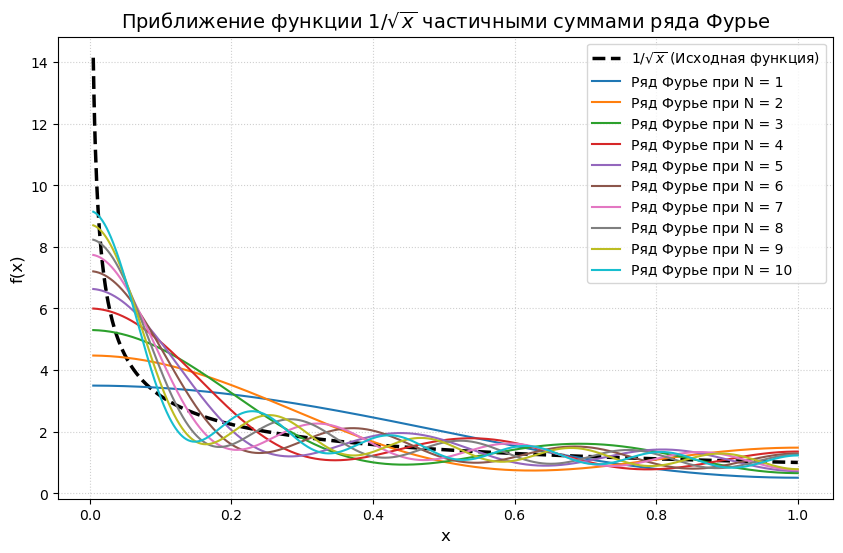

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import fresnel

# 1. Задаем отрезок x (исключая точный 0, чтобы избежать деления на ноль)
x = np.linspace(0.005, 1.0, 1000)
y_exact = 1 / np.sqrt(x)

# 2. Функция для вычисления частичной суммы ряда Фурье по косинусам
def fourier_cosine_sum(N, x_vec):
    # Нулевой коэффициент (а0 / 2). Так как а0 = 4, начальное значение равно 2
    s = np.ones_like(x_vec) * 2
    
    for n in range(1, N + 1):
        # Вычисляем интеграл Френеля C(z) с помощью scipy
        # Аргумент подставляется с учетом нормировки под отрезок [0, 1]
        S, C = fresnel(np.sqrt(2 * n))
        
        # Коэффициент a_n
        an = (2 * np.sqrt(2) / np.sqrt(n)) * C
        
        # Добавляем очередную гармонику к общей сумме
        s += an * np.cos(np.pi * n * x_vec)
        
    return s

# 3. Настройка графика
plt.figure(figsize=(10, 6), dpi=100)

# Рисуем саму функцию (пунктиром)
plt.plot(x, y_exact, 'k--', label='$1/\\sqrt{x}$ (Исходная функция)', linewidth=2.5)

# Строим приближения для разного числа гармоник N
harmonics = np.linspace(1, 10, 10, dtype=int)
for N in harmonics:
    plt.plot(x, fourier_cosine_sum(N, x), label=f'Ряд Фурье при N = {N}')

# 4. Оформление осей и сетки
# plt.ylim(0, 5)  # Ограничиваем по Y, так как функция уходит в бесконечность
# plt.xlim(0, 1)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Приближение функции $1/\\sqrt{x}$ частичными суммами ряда Фурье', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# Показываем график
plt.show()